In [ ]:
# Cell 1. import libraries

from pathlib import Path
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights

# reproducibility
SEED = 42
random.seed(SEED) 
np.random.seed(SEED)     # Fixes randomness in numpy
torch.manual_seed(SEED)  # Fixes randomness in pytorch
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED) # Fixes randomness in gpu

# GPU settings
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Uređaj za treniranje: {device}")
if device.type == "cuda":
    print(f"Grafička kartica: {torch.cuda.get_device_name(0)}")

Uređaj za treniranje: cuda
Grafička kartica: NVIDIA GeForce RTX 3060 Laptop GPU


In [12]:
# Cell 2.
# Configure dataset directories

DATA_DIR = Path("./dataset")  
TRAIN_DIR = DATA_DIR / "Croped_train"
TEST_DIR = DATA_DIR / "Croped_test"

BATCH_SIZE = 32
IMG_SIZE = (224, 224)
MODEL_SAVE_PATH = Path("./best_model.pth")

In [13]:
# Cell 3.
# Check folder contents and image counts per class

valid_exts = {".jpg", ".jpeg", ".png", ".bmp"}

for name, path in [("TRAIN", TRAIN_DIR), ("TEST", TEST_DIR)]:
    print(f"\n--- {name} DATASET ---")
    for cls_folder in sorted(p for p in path.iterdir() if p.is_dir()):
        count = sum(1 for f in cls_folder.iterdir() if f.suffix.lower() in valid_exts)
        print(f"{cls_folder.name:<12}: {count} images")


--- TRAIN DATASET ---
glioma_tumor: 740 images
meningioma_tumor: 749 images
no_tumor    : 393 images
pituitary_tumor: 720 images

--- TEST DATASET ---
glioma_tumor: 186 images
meningioma_tumor: 188 images
no_tumor    : 96 images
pituitary_tumor: 181 images


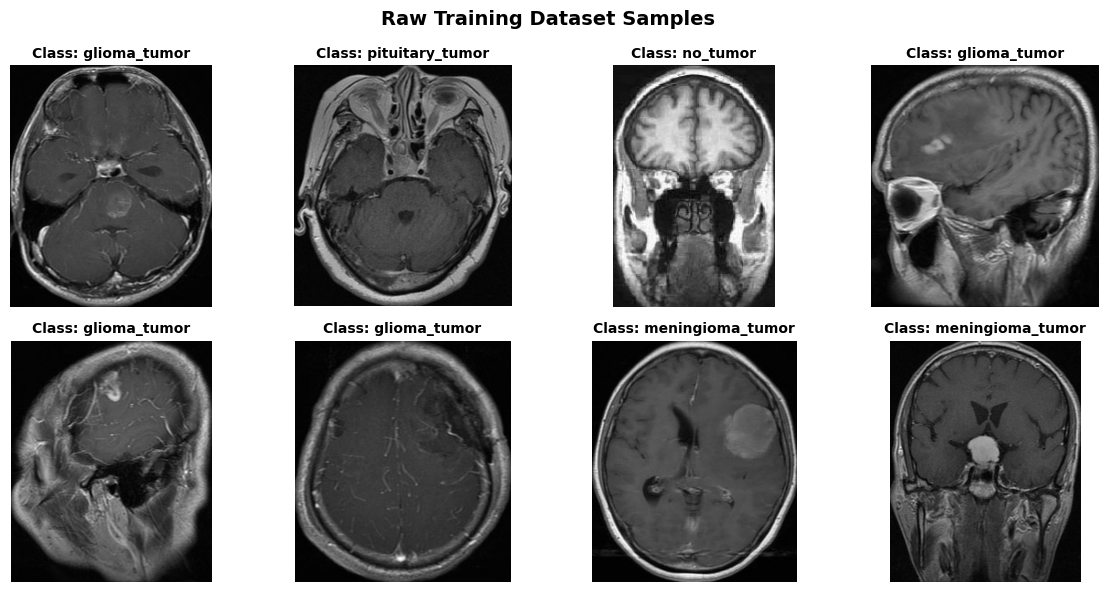

In [ ]:
# Cell 4. Visualize Sample Training Images

import random
import matplotlib.pyplot as plt
from PIL import Image

# Load raw dataset directly without transforms to view original images
raw_train_dataset = datasets.ImageFolder(root=str(TRAIN_DIR))
CLASSES = raw_train_dataset.classes

# Set up grid (2 rows, 4 columns = 8 samples)
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
axes = axes.flatten()

# Pick 8 random indices
random_indices = random.sample(range(len(raw_train_dataset)), 8)

for i, idx in enumerate(random_indices):
    img, label_idx = raw_train_dataset[idx]  # Returns PIL image and class index
    class_name = CLASSES[label_idx]
    
    axes[i].imshow(img)
    axes[i].set_title(f"Class: {class_name}", fontsize=10, fontweight="bold")
    axes[i].axis("off")

plt.suptitle("Raw Training Dataset Samples", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

In [ ]:
# Cell 5. Transformations and data loading (DataLoader)

# Standard ImageNet normalization values recommended for EfficientNet
mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]

# Data Augmentation for Training
train_transform = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std)
])

# Evaluation Transform (Validation and Testing)
val_test_transform = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std)
])

# Load full dataset from Croped_train
full_train_dataset = datasets.ImageFolder(root=str(TRAIN_DIR), transform=train_transform)
CLASSES = full_train_dataset.classes
print(f"Classification classes: {CLASSES}")

# Split into 75% Training and 25% Validation
train_size = int(0.75 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size

generator = torch.Generator().manual_seed(SEED)
train_ds, val_ds = random_split(full_train_dataset, [train_size, val_size], generator=generator)

# Apply evaluation transform to validation subset
val_ds.dataset.transform = val_test_transform

# Load test dataset from Croped_test
test_dataset = datasets.ImageFolder(root=str(TEST_DIR), transform=val_test_transform)

# DataLoaders
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f"Training images count: {len(train_ds)}")
print(f"Validation images count: {len(val_ds)}")
print(f"Test images count: {len(test_dataset)}")

Classification classes: ['glioma_tumor', 'meningioma_tumor', 'no_tumor', 'pituitary_tumor']
Training images count: 1951
Validation images count: 651
Test images count: 651


In [19]:
# Cell 6. Build model
# Transfer learning setup with EfficientNetB0 backbone

# Load pre-trained EfficientNetB0 model
weights = EfficientNet_B0_Weights.DEFAULT
model = efficientnet_b0(weights=weights)

# Phase 1: Freeze base model parameters
for param in model.parameters():
    param.requires_grad = False

# Replace classification head
in_features = model.classifier[1].in_features
model.classifier = nn.Sequential(
    nn.Dropout(p=0.4),
    nn.Linear(in_features, len(CLASSES))
)

model = model.to(device)
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to C:\Users\tomo/.cache\torch\hub\checkpoints\efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:02<00:00, 8.47MB/s]


In [20]:
# Cell 7.
# Helper Functions for Training and Epoch Evaluation

def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for inputs, labels in loader:
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * inputs.size(0)
        _, preds = outputs.max(1)
        correct += preds.eq(labels).sum().item()
        total += labels.size(0)
        
    return running_loss / total, correct / total

def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item() * inputs.size(0)
            _, preds = outputs.max(1)
            correct += preds.eq(labels).sum().item()
            total += labels.size(0)
            
    return running_loss / total, correct / total

In [ ]:
# Cell 8.
# Training Phase 1 (Classifier Head Only)

print("--- Phase 1: Training Classification Head ---")
optimizer_phase1 = optim.Adam(model.classifier.parameters(), lr=1e-3)
scheduler_phase1 = optim.lr_scheduler.ReduceLROnPlateau(optimizer_phase1, mode='min', factor=0.2, patience=2)

EPOCHS_PHASE1 = 20
best_val_loss = float('inf')

history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

for epoch in range(EPOCHS_PHASE1):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer_phase1, device)
    val_loss, val_acc = evaluate(model, val_loader, criterion, device)
    
    scheduler_phase1.step(val_loss)
    
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)
    
    print(f"Epoch {epoch+1:02d}/{EPOCHS_PHASE1:02d} | "
          f"Train Loss: {train_loss:.4f} - Acc: {train_acc*100:.2f}% | "
          f"Val Loss: {val_loss:.4f} - Acc: {val_acc*100:.2f}%")
    
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), MODEL_SAVE_PATH)

--- Phase 1: Training Classification Head ---
Epoch 01/15 | Train Loss: 1.0659 - Acc: 60.58% | Val Loss: 0.8997 - Acc: 74.50%
Epoch 02/15 | Train Loss: 0.8334 - Acc: 76.11% | Val Loss: 0.7779 - Acc: 77.88%
Epoch 03/15 | Train Loss: 0.7741 - Acc: 79.55% | Val Loss: 0.7454 - Acc: 80.34%
Epoch 04/15 | Train Loss: 0.7403 - Acc: 81.09% | Val Loss: 0.7300 - Acc: 82.03%
Epoch 05/15 | Train Loss: 0.7194 - Acc: 81.70% | Val Loss: 0.7202 - Acc: 82.33%
Epoch 06/15 | Train Loss: 0.7031 - Acc: 83.34% | Val Loss: 0.7116 - Acc: 82.95%
Epoch 07/15 | Train Loss: 0.7087 - Acc: 82.68% | Val Loss: 0.6992 - Acc: 83.10%
Epoch 08/15 | Train Loss: 0.6885 - Acc: 84.42% | Val Loss: 0.6971 - Acc: 83.41%
Epoch 09/15 | Train Loss: 0.6869 - Acc: 84.57% | Val Loss: 0.6928 - Acc: 83.72%
Epoch 10/15 | Train Loss: 0.6761 - Acc: 84.11% | Val Loss: 0.6888 - Acc: 83.26%
Epoch 11/15 | Train Loss: 0.6849 - Acc: 84.06% | Val Loss: 0.6897 - Acc: 84.02%
Epoch 12/15 | Train Loss: 0.6556 - Acc: 86.26% | Val Loss: 0.6833 - Acc: 8

In [ ]:
# Cell 9.
# Training Phase 2 (Unfreeze All Layers & Fine-Tuning)

print("\n--- Phase 2: Fine-Tuning Entire Model ---")

# Unfreeze all model parameters
for param in model.parameters():
    param.requires_grad = True

# Lower learning rate for fine-tuning
optimizer_phase2 = optim.Adam(model.parameters(), lr=1e-5)
scheduler_phase2 = optim.lr_scheduler.ReduceLROnPlateau(optimizer_phase2, mode='min', factor=0.2, patience=2)

EPOCHS_PHASE2 = 20
patience = 4
patience_counter = 0

for epoch in range(EPOCHS_PHASE2):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer_phase2, device)
    val_loss, val_acc = evaluate(model, val_loader, criterion, device)
    
    scheduler_phase2.step(val_loss)
    
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)
    
    print(f"Epoch {epoch+1:02d}/{EPOCHS_PHASE2:02d} | "
          f"Train Loss: {train_loss:.4f} - Acc: {train_acc*100:.2f}% | "
          f"Val Loss: {val_loss:.4f} - Acc: {val_acc*100:.2f}%")
    
    # Save Checkpoint & Early Stopping Check
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), MODEL_SAVE_PATH)
        patience_counter = 0
        print(f"-> Best weights saved to {MODEL_SAVE_PATH}")
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print("[INFO] Early stopping triggered. Training stopped.")
            break




--- Phase 2: Fine-Tuning Entire Model ---
Epoch 01/10 | Train Loss: 0.6429 - Acc: 86.62% | Val Loss: 0.6620 - Acc: 84.18%
-> Best weights saved to best_model.pth
Epoch 02/10 | Train Loss: 0.6218 - Acc: 88.21% | Val Loss: 0.6482 - Acc: 85.10%
-> Best weights saved to best_model.pth
Epoch 03/10 | Train Loss: 0.5893 - Acc: 90.01% | Val Loss: 0.6384 - Acc: 85.87%
-> Best weights saved to best_model.pth
Epoch 04/10 | Train Loss: 0.5860 - Acc: 90.72% | Val Loss: 0.6281 - Acc: 86.48%
-> Best weights saved to best_model.pth
Epoch 05/10 | Train Loss: 0.5607 - Acc: 91.75% | Val Loss: 0.6199 - Acc: 87.86%
-> Best weights saved to best_model.pth
Epoch 06/10 | Train Loss: 0.5477 - Acc: 93.13% | Val Loss: 0.6142 - Acc: 87.71%
-> Best weights saved to best_model.pth
Epoch 07/10 | Train Loss: 0.5499 - Acc: 92.67% | Val Loss: 0.6061 - Acc: 87.86%
-> Best weights saved to best_model.pth
Epoch 08/10 | Train Loss: 0.5199 - Acc: 94.11% | Val Loss: 0.5989 - Acc: 88.17%
-> Best weights saved to best_model.p


--- Classification Report (Croped_test) ---
                  precision    recall  f1-score   support

    glioma_tumor       0.90      0.87      0.88       186
meningioma_tumor       0.83      0.85      0.84       188
        no_tumor       0.86      0.92      0.89        96
 pituitary_tumor       0.92      0.91      0.91       181

        accuracy                           0.88       651
       macro avg       0.88      0.88      0.88       651
    weighted avg       0.88      0.88      0.88       651



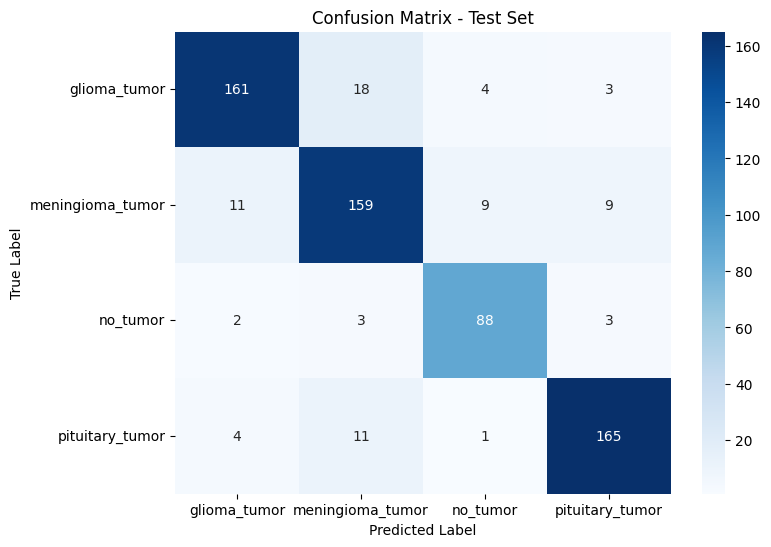

In [23]:
# Cell 10: Test Set Evaluation & Confusion Matrix

# Load best performing weights
model.load_state_dict(torch.load(MODEL_SAVE_PATH))
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        _, preds = outputs.max(1)
        
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

# Display Classification Report
print("\n--- Classification Report (Croped_test) ---")
print(classification_report(all_labels, all_preds, target_names=CLASSES))

# Plot Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CLASSES, yticklabels=CLASSES)
plt.title('Confusion Matrix - Test Set')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

--- Processing Single Image: nova_slika.jpg ---


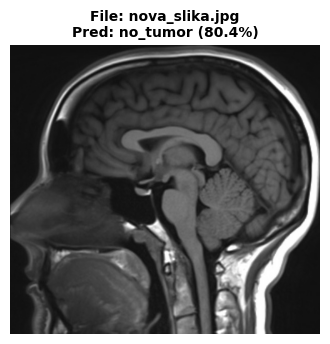

In [25]:
from pathlib import Path
import torch
import torch.nn.functional as F
from PIL import Image
import matplotlib.pyplot as plt

def predict_and_display(image_path, model, device, class_names, transform):
    """
    Runs inference on a single image file and displays the output.
    """
    raw_img = Image.open(image_path).convert("RGB")
    input_tensor = transform(raw_img).unsqueeze(0).to(device)  # Add batch dimension
    
    model.eval()
    with torch.no_grad():
        outputs = model(input_tensor)
        probabilities = F.softmax(outputs, dim=1)
        confidence, predicted_idx = torch.max(probabilities, 1)
        
    predicted_class = class_names[predicted_idx.item()]
    confidence_score = confidence.item() * 100
    
    plt.figure(figsize=(4, 4))
    plt.imshow(raw_img)
    plt.axis("off")
    plt.title(f"File: {image_path.name}\nPred: {predicted_class} ({confidence_score:.1f}%)", 
              fontsize=10, fontweight="bold")
    plt.show()
    
    return predicted_class, confidence_score

def run_inference(input_path, model, device, class_names):
    """
    Loads model weights and processes either a single image file or an entire folder of images.
    """
    # Define evaluation transform matching validation setup
    inference_transform = transforms.Compose([
        transforms.Resize(IMG_SIZE),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    
    # Ensure best saved weights are loaded
    model.load_state_dict(torch.load(MODEL_SAVE_PATH))
    
    path = Path(input_path)
    valid_extensions = {".jpg", ".jpeg", ".png", ".bmp"}
    
    # Case 1: Single Image File
    if path.is_file() and path.suffix.lower() in valid_extensions:
        print(f"--- Processing Single Image: {path.name} ---")
        predict_and_display(path, model, device, class_names, inference_transform)
        
    # Case 2: Folder of Images
    elif path.is_dir():
        image_files = [f for f in path.iterdir() if f.suffix.lower() in valid_extensions]
        print(f"--- Found {len(image_files)} images in folder: {path.name} ---")
        
        for img_path in image_files:
            predict_and_display(img_path, model, device, class_names, inference_transform)
            
    else:
        print(f"Invalid path or no supported images found at: {input_path}")

# --- Usage Examples ---
# Option A: Path to a single image file
UNSEEN_INPUT = "./nova_slika.jpg"  

# Option B: Path to a folder containing multiple images
# UNSEEN_INPUT = "./unseen_folder/"  

run_inference(UNSEEN_INPUT, model, device, CLASSES)